In [1]:
import pandas as pd

train = pd.read_csv('../data/train.csv')
test = pd.read_csv('../data/test.csv')

print("Train shape:", train.shape)
print("Test shape:", test.shape)
train.head()

Train shape: (891, 12)
Test shape: (418, 11)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [2]:
print(train.info())
print()
print(train.isnull().sum())
print()
train.describe()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 118.9 KB
None

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64



,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


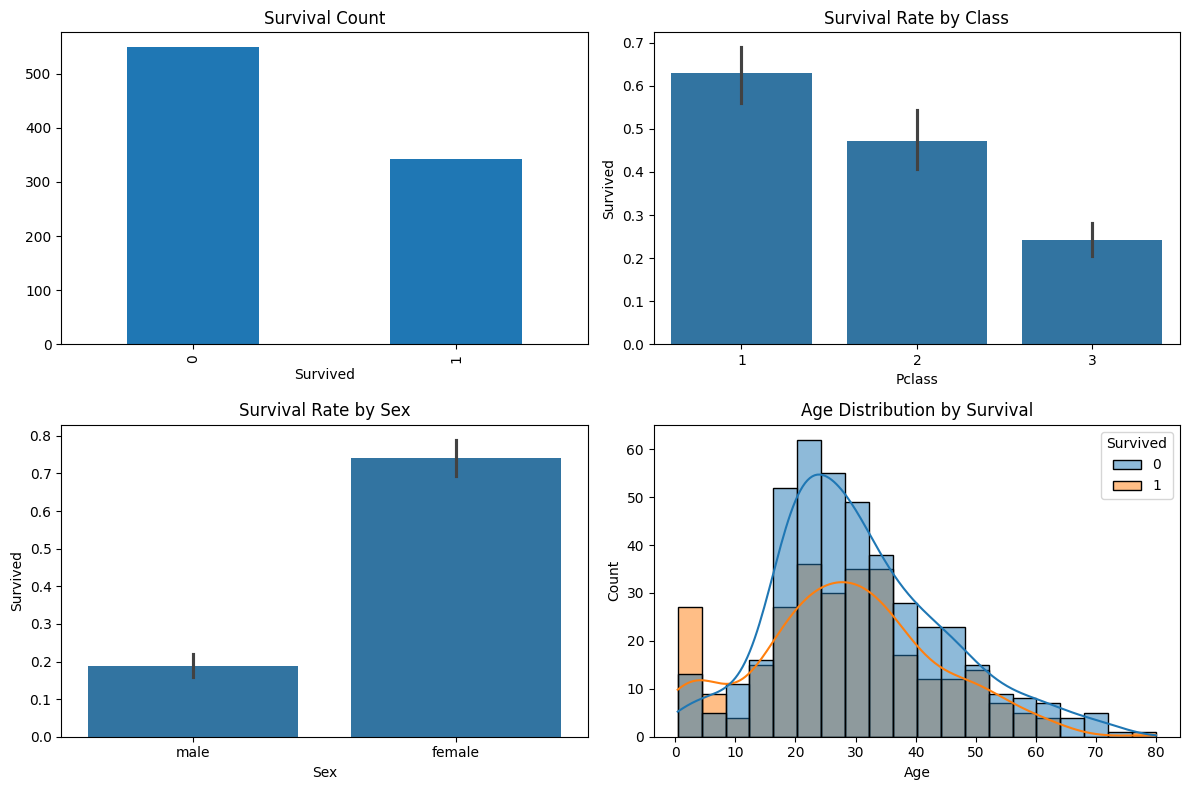

Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64
Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64


In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(12,8))

train['Survived'].value_counts().plot(kind='bar', ax=axes[0,0], title='Survival Count')
sns.barplot(data=train, x='Pclass', y='Survived', ax=axes[0,1])
axes[0,1].set_title('Survival Rate by Class')
sns.barplot(data=train, x='Sex', y='Survived', ax=axes[1,0])
axes[1,0].set_title('Survival Rate by Sex')
sns.histplot(data=train, x='Age', hue='Survived', kde=True, ax=axes[1,1])
axes[1,1].set_title('Age Distribution by Survival')

plt.tight_layout()
plt.show()

print(train.groupby('Pclass')['Survived'].mean())
print(train.groupby('Sex')['Survived'].mean())

In [4]:
def engineer_features(df):
    df = df.copy()
    
    # Family size features
    df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
    df['IsAlone'] = (df['FamilySize'] == 1).astype(int)
    
    # Title extraction from Name
    df['Title'] = df['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)
    df['Title'] = df['Title'].replace(['Lady', 'Countess', 'Capt', 'Col', 'Don', 'Dr',
                                        'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona'], 'Rare')
    df['Title'] = df['Title'].replace('Mlle', 'Miss')
    df['Title'] = df['Title'].replace('Ms', 'Miss')
    df['Title'] = df['Title'].replace('Mme', 'Mrs')
    
    # Cabin deck (first letter), missing -> 'U' for Unknown
    df['Deck'] = df['Cabin'].str[0]
    df['Deck'] = df['Deck'].fillna('U')
    
    return df

train_fe = engineer_features(train)
test_fe = engineer_features(test)

print(train_fe['Title'].value_counts())
print(train_fe.groupby('Title')['Survived'].mean())

Title
Mr        517
Miss      185
Mrs       126
Master     40
Rare       23
Name: count, dtype: int64
Title
Master    0.575000
Miss      0.702703
Mr        0.156673
Mrs       0.793651
Rare      0.347826
Name: Survived, dtype: float64


In [5]:
def handle_missing(df, age_medians_by_title=None):
    df = df.copy()
    
    if age_medians_by_title is None:
        age_medians_by_title = df.groupby('Title')['Age'].median()
    
    for title in age_medians_by_title.index:
        mask = (df['Title'] == title) & (df['Age'].isnull())
        df.loc[mask, 'Age'] = age_medians_by_title[title]
    
    df['Age'] = df['Age'].fillna(df['Age'].median())  # fallback for unseen titles
    df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
    df['Fare'] = df['Fare'].fillna(df['Fare'].median())
    
    return df, age_medians_by_title

train_fe, age_medians = handle_missing(train_fe)
test_fe, _ = handle_missing(test_fe, age_medians_by_title=age_medians)

print(train_fe.isnull().sum())
print(test_fe.isnull().sum())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         0
FamilySize       0
IsAlone          0
Title            0
Deck             0
dtype: int64
PassengerId      0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          327
Embarked         0
FamilySize       0
IsAlone          0
Title            0
Deck             0
dtype: int64


In [6]:
from sklearn.preprocessing import LabelEncoder

features = ['Pclass', 'Sex', 'Age', 'Fare', 'Embarked', 'FamilySize', 'IsAlone', 'Title', 'Deck']

def encode_features(train_df, test_df, features):
    train_enc = train_df[features].copy()
    test_enc = test_df[features].copy()
    
    cat_cols = ['Sex', 'Embarked', 'Title', 'Deck']
    encoders = {}
    
    for col in cat_cols:
        le = LabelEncoder()
        combined = pd.concat([train_enc[col], test_enc[col]], axis=0)
        le.fit(combined)
        train_enc[col] = le.transform(train_enc[col])
        test_enc[col] = le.transform(test_enc[col])
        encoders[col] = le
    
    return train_enc, test_enc, encoders

X = train_fe[features]
y = train_fe['Survived']

X_encoded, test_encoded, encoders = encode_features(train_fe, test_fe, features)

X_encoded.head()

,Pclass,Sex,Age,Fare,Embarked,FamilySize,IsAlone,Title,Deck
0,3,1,22.0,7.2500,2,2,0,2,8
1,1,0,38.0,71.2833,0,2,0,3,2
2,3,0,26.0,7.9250,2,1,1,1,8
3,1,0,35.0,53.1000,2,2,0,3,2
4,3,1,35.0,8.0500,2,1,1,2,8


In [7]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report

X_train, X_val, y_train, y_val = train_test_split(X_encoded, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "KNN": KNeighborsClassifier(),
    "SVM": SVC(probability=True),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
}

results = {}

for name, model in models.items():
    if name in ["KNN", "SVM", "Logistic Regression"]:
        model.fit(X_train_scaled, y_train)
        preds = model.predict(X_val_scaled)
    else:
        model.fit(X_train, y_train)
        preds = model.predict(X_val)
    
    acc = accuracy_score(y_val, preds)
    results[name] = acc
    print(f"--- {name} ---")
    print(f"Accuracy: {acc:.4f}")
    print(classification_report(y_val, preds))

results

--- Logistic Regression ---
Accuracy: 0.7989
              precision    recall  f1-score   support

           0       0.83      0.85      0.84       110
           1       0.75      0.72      0.74        69

    accuracy                           0.80       179
   macro avg       0.79      0.79      0.79       179
weighted avg       0.80      0.80      0.80       179

--- KNN ---
Accuracy: 0.7933
              precision    recall  f1-score   support

           0       0.82      0.85      0.83       110
           1       0.74      0.71      0.73        69

    accuracy                           0.79       179
   macro avg       0.78      0.78      0.78       179
weighted avg       0.79      0.79      0.79       179



c:\Users\om.ak\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


--- SVM ---
Accuracy: 0.8324
              precision    recall  f1-score   support

           0       0.84      0.90      0.87       110
           1       0.82      0.72      0.77        69

    accuracy                           0.83       179
   macro avg       0.83      0.81      0.82       179
weighted avg       0.83      0.83      0.83       179

--- Random Forest ---
Accuracy: 0.7877
              precision    recall  f1-score   support

           0       0.81      0.86      0.83       110
           1       0.75      0.67      0.71        69

    accuracy                           0.79       179
   macro avg       0.78      0.77      0.77       179
weighted avg       0.79      0.79      0.78       179



c:\Users\om.ak\AppData\Local\Programs\Python\Python314\Lib\site-packages\xgboost\training.py:200: UserWarning: [11:31:35] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:794: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


--- XGBoost ---
Accuracy: 0.7709
              precision    recall  f1-score   support

           0       0.81      0.82      0.81       110
           1       0.71      0.70      0.70        69

    accuracy                           0.77       179
   macro avg       0.76      0.76      0.76       179
weighted avg       0.77      0.77      0.77       179



{'Logistic Regression': 0.7988826815642458,
 'KNN': 0.7932960893854749,
 'SVM': 0.8324022346368715,
 'Random Forest': 0.7877094972067039,
 'XGBoost': 0.770949720670391}

In [8]:
from sklearn.model_selection import cross_val_score

cv_results = {}

for name, model in models.items():
    if name in ["KNN", "SVM", "Logistic Regression"]:
        scores = cross_val_score(model, scaler.fit_transform(X_encoded), y, cv=5, scoring='accuracy')
    else:
        scores = cross_val_score(model, X_encoded, y, cv=5, scoring='accuracy')
    cv_results[name] = scores.mean()
    print(f"{name}: {scores.mean():.4f} (+/- {scores.std():.4f})")

cv_results

Logistic Regression: 0.7946 (+/- 0.0124)
KNN: 0.8137 (+/- 0.0267)


c:\Users\om.ak\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\om.ak\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\om.ak\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\om.ak\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\svm\

SVM: 0.8305 (+/- 0.0308)
Random Forest: 0.8081 (+/- 0.0287)


c:\Users\om.ak\AppData\Local\Programs\Python\Python314\Lib\site-packages\xgboost\training.py:200: UserWarning: [11:32:17] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:794: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\om.ak\AppData\Local\Programs\Python\Python314\Lib\site-packages\xgboost\training.py:200: UserWarning: [11:32:17] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:794: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\om.ak\AppData\Local\Programs\Python\Python314\Lib\site-packages\xgboost\training.py:200: UserWarning: [11:32:18] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:794: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\om.ak\AppData\Local\Programs\Python\Python314\Lib\site-packages\xgboost\training.py:200: UserWarning: [11:32:18] WARNING: C:\actio

XGBoost: 0.8216 (+/- 0.0217)


{'Logistic Regression': np.float64(0.7946268281965978),
 'KNN': np.float64(0.8136902893729208),
 'SVM': np.float64(0.830500282468144),
 'Random Forest': np.float64(0.8080911430544221),
 'XGBoost': np.float64(0.8215554579122465)}

In [9]:
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(probability=True))
])

param_grid = {
    'svm__C': [0.1, 1, 10],
    'svm__kernel': ['rbf', 'linear'],
    'svm__gamma': ['scale', 'auto']
}

grid = GridSearchCV(pipeline, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid.fit(X_encoded, y)

print("Best params:", grid.best_params_)
print("Best CV score:", grid.best_score_)

best_model = grid.best_estimator_

Best params: {'svm__C': 1, 'svm__gamma': 'scale', 'svm__kernel': 'rbf'}
Best CV score: 0.831617600903898


c:\Users\om.ak\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


      feature  importance
1         Sex    0.247250
5  FamilySize    0.042200
7       Title    0.039057
0      Pclass    0.017733
4    Embarked    0.010774
8        Deck    0.007632
2         Age    0.005499
3        Fare    0.005275
6     IsAlone    0.002806


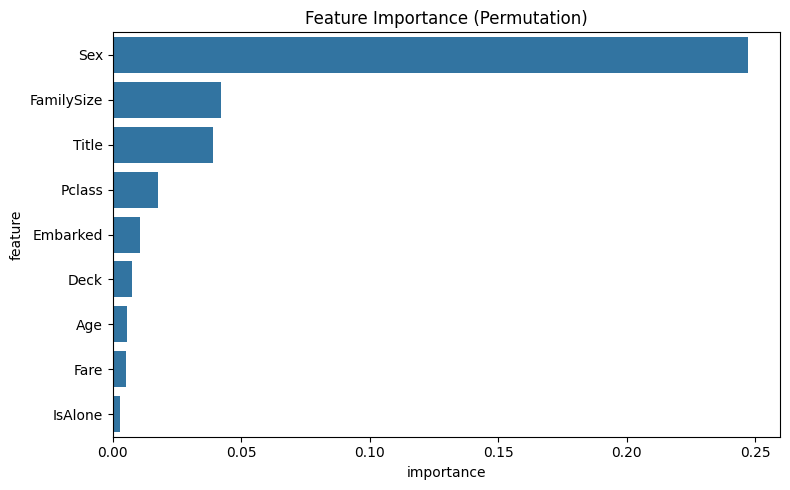

In [10]:
from sklearn.inspection import permutation_importance

result = permutation_importance(best_model, X_encoded, y, n_repeats=10, random_state=42, n_jobs=-1)

importance_df = pd.DataFrame({
    'feature': X_encoded.columns,
    'importance': result.importances_mean
}).sort_values('importance', ascending=False)

print(importance_df)

plt.figure(figsize=(8,5))
sns.barplot(data=importance_df, x='importance', y='feature')
plt.title('Feature Importance (Permutation)')
plt.tight_layout()
plt.show()

In [11]:
import joblib

joblib.dump(best_model, '../models/titanic_svm_model.pkl')
joblib.dump(encoders, '../models/titanic_encoders.pkl')
joblib.dump(age_medians, '../models/age_medians.pkl')

print("Model, encoders, and age medians saved!")

Model, encoders, and age medians saved!


C:\Users\om.ak\AppData\Local\Temp\ipykernel_13856\106352592.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(results.keys(), rotation=30, ha='right')


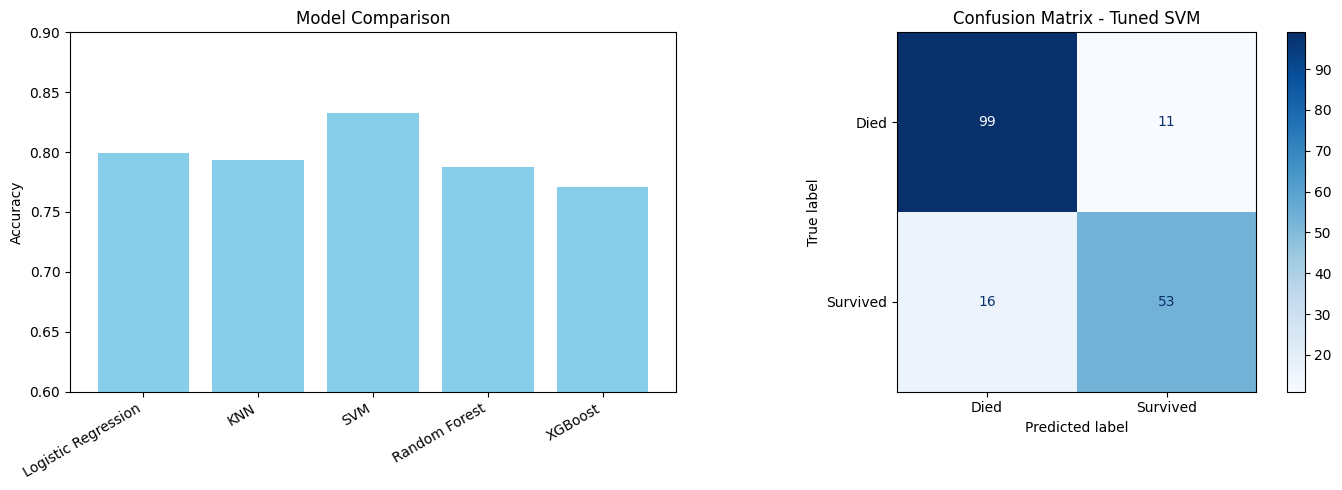

In [12]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 2, figsize=(14,5))

axes[0].bar(results.keys(), results.values(), color='skyblue')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Model Comparison')
axes[0].set_xticklabels(results.keys(), rotation=30, ha='right')
axes[0].set_ylim(0.6, 0.9)

val_preds = best_model.predict(X_val)
ConfusionMatrixDisplay.from_predictions(y_val, val_preds, display_labels=['Died','Survived'], cmap='Blues', ax=axes[1])
axes[1].set_title('Confusion Matrix - Tuned SVM')

plt.tight_layout()
plt.savefig('../images/model_comparison_confusion.png')
plt.show()

## Summary

- **Dataset:** Kaggle Titanic dataset (891 train, 418 test)
- **Feature engineering:** FamilySize, IsAlone, Title (extracted from Name), Deck (from Cabin)
- **Missing value handling:** Age imputed via Title-wise median; Embarked via mode; Cabin dropped in favor of Deck
- **Best model:** SVM (RBF kernel, C=1) — 83.16% cross-validated accuracy
- **Tuning:** GridSearchCV confirmed optimal SVM hyperparameters
- **Explainability:** Permutation importance shows Sex is by far the dominant predictor (0.247), followed by FamilySize and Title
- **Key insight:** "Women and children first" — female survival rate 74.2% vs male 18.9%; 1st class 63.0% vs 3rd class 24.2%
- **Artifacts saved:** `titanic_svm_model.pkl`, `titanic_encoders.pkl`, `age_medians.pkl`